# 主管架构
> 主管（Supervisor）架构是多智能体系统中的核心模式，当需要明确的编排点来管理和指导任务流时，它尤其有效。在这种架构中，指定的主管智能体充当中央协调员的角色，监督和指导多个专业智能体的活动。

## langgraph-supervisor
> 它允许你创建一个中央的 “supervisor” 代理，负责接收用户输入、判断任务类型，并将任务分派给对应的 “worker” 专家代理。

### 消息传递的方式
通过参数指定‘output_mode’：
* last_message：
    * 仅传递最后一条消息
* full_history：
    * 传递所有消息

In [3]:
from langchain_openai import ChatOpenAI
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent
import os
from dotenv import load_dotenv

load_dotenv()


True

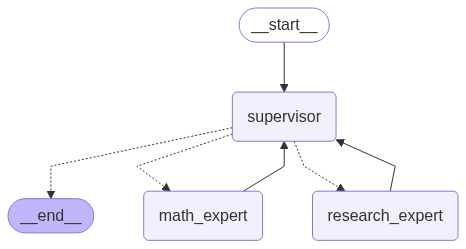

In [ ]:
model = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)

# 1. 为专业智能体定义工具：
# 定义表示每个专业智能体工具的函数。
# 'add' 和 'multiply' 用于数学智能体，'web_search' 用于研究智能体。
def add(a: float, b: float) -> float:
    """添加两个数字。"""
    return a + b

def multiply(a: float, b: float) -> float:
    """乘两个数字。"""
    return a * b

def web_search(query: str) -> str:
    """在网络上搜索信息。"""
    return (
        "以下是 FAANG 公司 2024 年的员工人数：\n"
        "1. **Facebook (Meta)**: 67,317 名员工。\n"
        "2. **Apple**: 164,000 名员工。\n"
        "3. **Amazon**: 1,551,000 名员工。\n"
        "4. **Netflix**: 14,000 名员工。\n"
        "5. **Google (Alphabet)**: 181,269 名员工。"
    )
# 2. 使用 create_react_agent 创建专业智能体：
# 使用 LangGraph 的预构建 create_react_agent 创建每个专业智能体。
# 每个智能体都配置了特定的模型、工具、名称和提示。
math_agent = create_react_agent(
    model=model,
    tools=[add, multiply], # 数学智能体的工具是 'add' 和 'multiply'
    name="math_expert", # 标识数学智能体的名称
    prompt="你是一名数学专家。始终一次使用一个工具。" # 指导数学智能体行为的提示
)

research_agent = create_react_agent(
    model=model,
    tools=[web_search], # 研究智能体的工具是 'web_search'
    name="research_expert", # 标识研究智能体的名称
    prompt="你是一名世界一流的研究员，可以访问网络搜索。不要做任何数学运算。" # 指导研究智能体行为的提示
)

# 3. 使用 create_supervisor 创建主管工作流：
# 使用 LangGraph Supervisor 的 create_supervisor 创建主管工作流。
# 传递专业智能体列表、主管模型以及主管的提示。
workflow = create_supervisor(
    [research_agent, math_agent], # 由主管管理的专业智能体列表
    model=model, # 主管智能体的模型
    output_mode="last_message", # 主管智能体的输出模式
    prompt="你是一名团队主管，管理着一名研究专家和一名数学专家。研究专家能够利用网络搜索工具进行查询。", # 指导主管行为的提示
)

# 4. 编译并运行工作流：
# 将工作流编译为 LangGraph 应用程序，并使用用户消息调用它。
app = workflow.compile() # 将工作流编译为可执行的 LangGraph 应用程序

from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [6]:
result = app.invoke({ # 使用用户消息调用已编译的应用程序
    "messages": [
        {
            "role": "user",
            "content": "2024 年 FAANG 公司的总员工人数是多少？为什么" # 用户关于 FAANG 公司员工人数的查询
        }
    ]
})
print(result["messages"][-1].content)

2024 年 FAANG 公司的总员工人数如下：

- **Facebook (Meta)**: 67,317 人
- **Apple**: 164,000 人
- **Amazon**: 1,551,000 人
- **Netflix**: 14,000 人
- **Google (Alphabet)**: 181,269 人

这些公司员工数量的差异主要归因于以下因素：

1. **业务模式**：例如，Amazon 拥有庞大的物流和仓储网络，需要大量员工来维持运营，而 Netflix 更加依赖流媒体技术，员工需求相对较少。
2. **自动化程度**：像 Google 和 Apple 这样的公司高度依赖技术和自动化，因此在运营中需要的员工相对较少。
3. **运营规模**：Amazon 的全球业务范围非常广泛，包括零售、云计算和人工智能等多个领域，导致其员工人数远远超过其他 FAANG 公司。

如果需要更详细的分析，我可以进一步提供帮助！
